,user_id,item_id,category_id,behavior_type,timestamp,date
0,1000028,1850341,2025483,pv,2017-11-26 16:23:03,2017-11-26
1,1000028,2428956,1879194,pv,2017-11-27 08:57:46,2017-11-27
2,1000028,4717045,5071267,pv,2017-11-27 08:58:36,2017-11-27
3,1000028,5049814,3002561,pv,2017-11-27 09:09:20,2017-11-27
4,1000028,2335149,4690421,pv,2017-11-27 09:09:27,2017-11-27


,PV,UV,人均浏览率
date,,,
2017-11-25,95006,6957,13.66
2017-11-26,99015,7051,14.04
2017-11-27,91568,6971,13.14
2017-11-28,91477,7024,13.02
2017-11-29,93256,7035,13.26
2017-11-30,92653,7135,12.99
2017-12-01,97201,7224,13.46
2017-12-02,125792,9518,13.22
2017-12-03,124836,9494,13.15


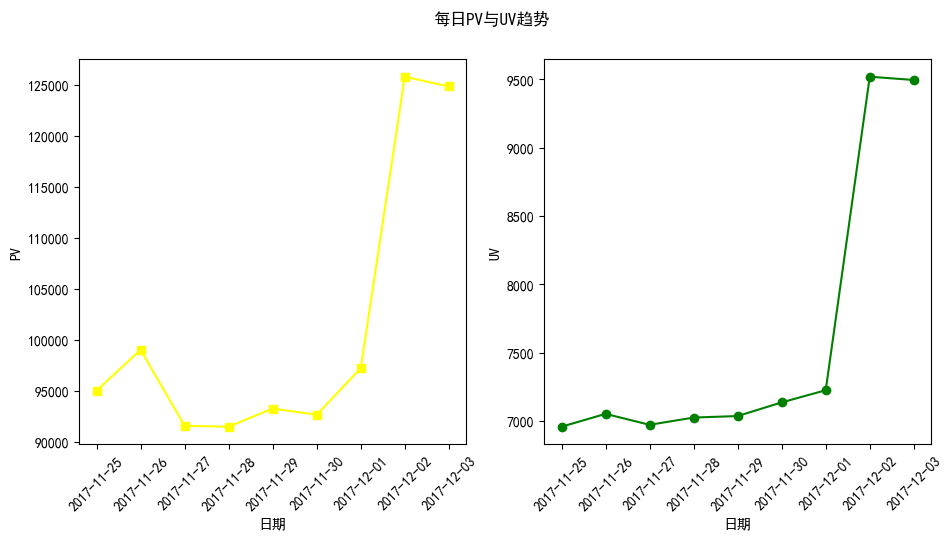

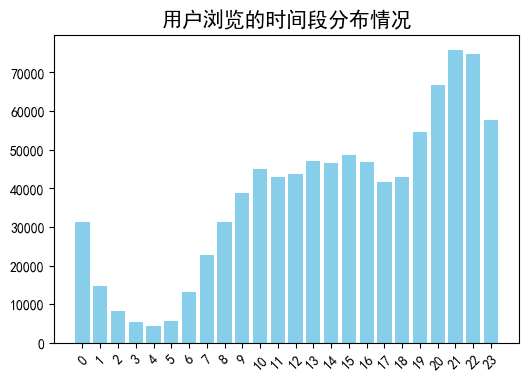

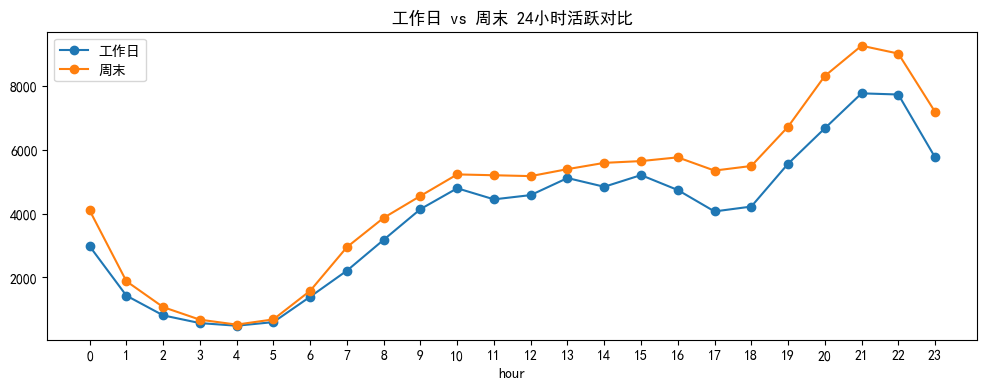

'对于pv行为来说，2017年11月30到12月2号浏览率在不断的提高，根据UV，可以看出用户数量也在上升，\n用户集中的浏览时间基本上集中在晚上7点和晚上10点，晚上9到10点浏览数量是对高的。'

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
rcParams['font.sans-serif']=['SimHei']
rcParams['axes.unicode_minus']=False
#将数据读取进来
df=pd.read_csv('../data/UserBehavior_clean.csv',parse_dates=['timestamp'])
#查看一下前五行数据
display(df.head())
#先看看每日有多少人浏览,以及人均浏览率
pv_df=df[df['behavior_type']=="pv"]
daily=pv_df.groupby('date').agg(
    PV=('user_id','count'), #浏览记录条数
    UV=('user_id','nunique') #去重后的用户人数
)
daily['人均浏览量']=(daily['PV']/daily['UV']).round(2)
display(daily)
#把每日的浏览率转化为折线图
fig,axes=plt.subplots(1,2,figsize=(11,5))
axes[0].plot(daily.index.astype(str),daily['PV'],marker='s',color='yellow')
axes[0].set_ylabel('PV')
axes[0].set_xlabel('日期')
axes[0].tick_params(axis='x',rotation=45)
axes[1].plot(daily.index.astype(str),daily['UV'],marker='o',color='green')
axes[1].set_ylabel('UV')
axes[1].set_xlabel('日期')
axes[1].tick_params(axis='x',rotation=45)
plt.suptitle('每日PV与UV趋势')
plt.show()
#通过条形图展示用户一般集中在那个时间段浏览
pv_df['hour'] = pv_df['timestamp'].dt.hour
hour_df=pv_df.groupby('hour').agg(user_counts=('user_id','count'))
plt.figure(figsize=(6,4))
plt.bar(hour_df.index,hour_df['user_counts'],color='skyblue')
plt.xticks(range(0,24),rotation=45)
plt.title('用户浏览的时间段分布情况',fontsize=15)
plt.show()
#看看工作日和周末是否也是集中在相同的时间段浏览
pv_df['weekday'] = pv_df['timestamp'].dt.weekday          # 0=周一 ... 6=周日
pv_df['是否周末'] = pv_df['weekday'].isin([5, 6])
weekend_hourly = pv_df.groupby(['是否周末', 'hour']).size().unstack(0) #注意size是统计分组的条数,unstack是旋转成列，把长表旋转成宽表
weekend_hourly.columns = ['工作日', '周末'] #将列名False改为工作日，True改为周末
# 归一化：两个时段天数不同，不能直接比总量，先算日均
workdays=pv_df[pv_df['weekday']<5]['date'].nunique() #计算工作日多少天
weekend_days=pv_df[pv_df['weekday']>=5]['date'].nunique() #计算周末多少天
weekend_hourly['周末']=weekend_hourly['周末']/weekend_days
weekend_hourly['工作日']=weekend_hourly['工作日']/workdays
#绘制折线图
weekend_hourly.plot(figsize=(12,4), marker='o')
plt.title('工作日 vs 周末 24小时活跃对比')
plt.xticks(range(0, 24))
plt.show()

"""
现象：11/25-12/1 流量平稳（PV 在 9.2万-9.9万 之间波动），12/2（周六）PV 跳升至 12.58万，环比前一天 +29.4%，12/3 维持 12.48万 高位；
UV 同步从 7,224 涨至 9,518（+31.8%）。用户活跃峰值出现在 21-22点（约7.6万条，为全天最高），谷底在凌晨 4-5点（约0.5万条），
符合电商用户“晚间活跃、凌晨休眠”的典型作息。

原因：流量跳升由双重因素叠加——12/2-3 为周末 + 双12大促预热启动。

建议：① 大促预热对拉活效果显著，后续大促提前2-3天布局预热资源位；② Push推送和广告投放集中在 20:30-21:30，赶在流量峰值前触达用户；
③ 凌晨4-6点为流量谷底，适合安排系统维护、压缩广告预算。

附加发现：周末日均活跃全天各时段均高于工作日，晚21点高出约20%（约9,400 vs 7,800），推送排期无需分两套，但周末可适当加大投放量级。而且，
人均浏览量在流量高峰日不升反微降（13.66→13.15），说明本轮增长以拉新引流为主而非存量用户加深活跃；后续应关注这批大促新用户的留存转化（衔接04留存/漏斗分析）"""

#通过条形图来看看用户行为的分布情况(pv:点击,buy:购买,cart:加购,fav:收藏)
plt.figure(figsize=(6,4))
beha_index=df['behavior_type'].value_counts().index
beha_counts=df['behavior_type'].value_counts()
plt.bar(beha_index,beha_counts,color='yellow')
plt.title("2017年11月25日至12月3日用户行为分布",color='black',fontsize=20)
plt.xlabel('行为类型',fontsize=12)
plt.ylabel('数量',fontsize=12)
plt.legend(loc='upper left')
plt.xticks(rotation=0,fontsize=12)
plt.yticks(rotation=0,fontsize=12)
for x,y in zip(beha_index,beha_counts):
    plt.text(x,y+1,str(y),ha='center',va='bottom',fontsize=10)
plt.show()